Paquetes necesarios

Podremos hacer uso del mismo *environment* de la primera práctica, aunque en ocasiones pedirá instalar Pillow

In [2]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
img = cv2.imread('mandril.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

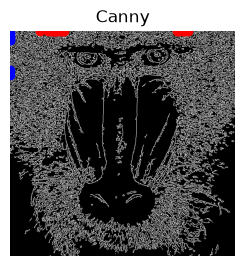

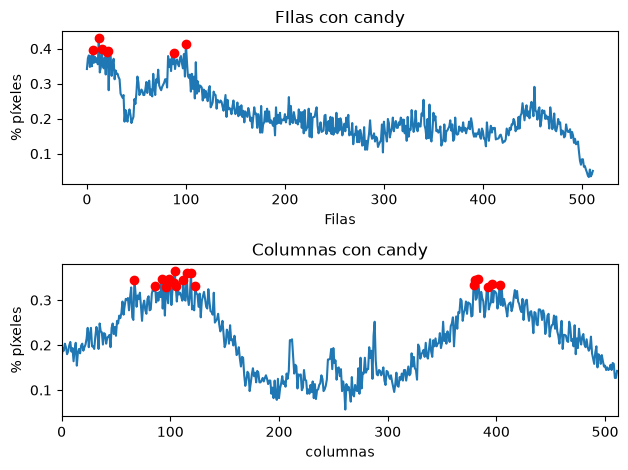

In [42]:
#El contenido de la imagen resultado de Canny, son valores 0 o 255, lo compruebas al descomentar
#print(canny)
#Cuenta el número de píxeles blancos (255) por fila
#Suma los valores de los pixeles por fila


def calculate_maxUmbral(val):
    max_val = np.max(val)
    umbral = max_val * 0.9
    position = np.where(val > umbral)[0]
    return max_val, umbral, position


gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(gris, 100, 200)

row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
col_counts = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)


#Normaliza en base al número de filas, primer valor devuelto por shape, y al valor máximo del píxel (255)
#Para poder nromalizarla tenemos que coger todo los valores de la primera dimensión y el primero de la segunda, [fila, fila]
rows_canny = row_counts[:,0] / (255 * canny.shape[1])
max_val_row_canny, umbral_row_canny, position_row_canny = calculate_maxUmbral(rows_canny)

cols_canny = col_counts[0] / (255 * canny.shape[0])
max_val_col_canny, umbral_col_canny, position_col_canny = calculate_maxUmbral(cols_canny)

#Muestra dicha cuenta gráficamente
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray') 
plt.plot(np.zeros_like(position_row_canny), position_row_canny, 'bo')  
plt.plot(position_col_canny, np.zeros_like(position_col_canny), 'ro')

plt.figure()
plt.subplot(2, 1, 1)
plt.title("FIlas con candy")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(rows_canny)
plt.plot(position_row_canny, rows_canny[position_row_canny], 'ro')


plt.subplot(2, 1, 2)
plt.title("Columnas con candy")
plt.xlabel("columnas")
plt.ylabel("% píxeles")
plt.plot(cols_canny)
plt.plot(position_col_canny, cols_canny[position_col_canny], 'ro')

#Rango en x definido por las columnas
plt.xlim([0, canny.shape[1]])
plt.tight_layout() # permite ajustar automáticamente los subplots para que no se solapen

TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

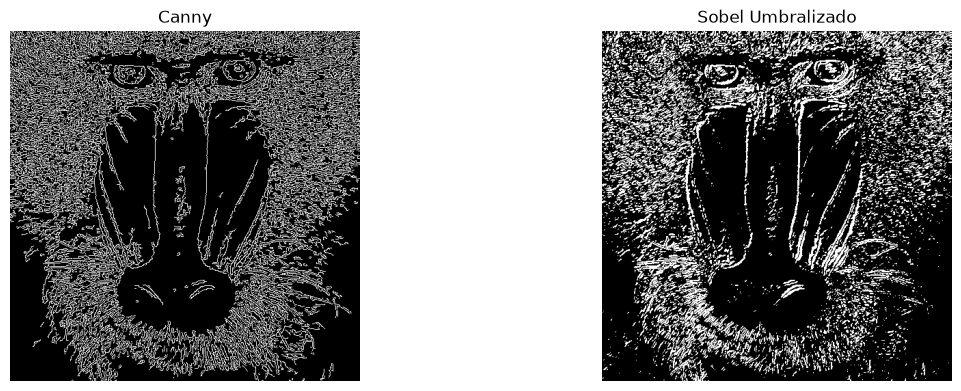

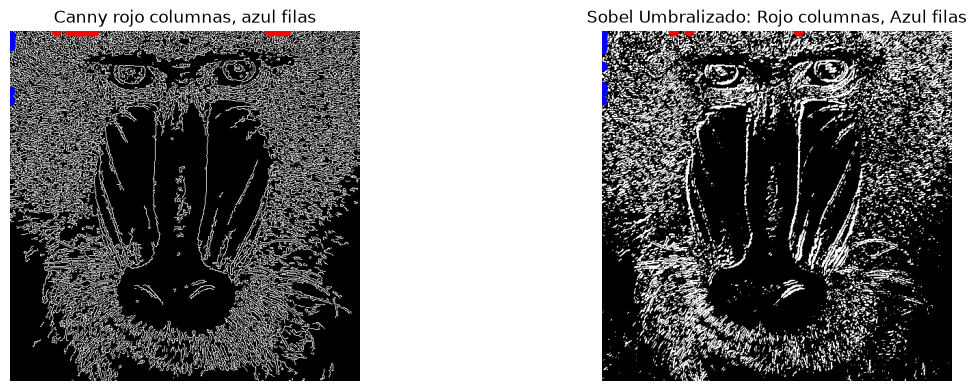

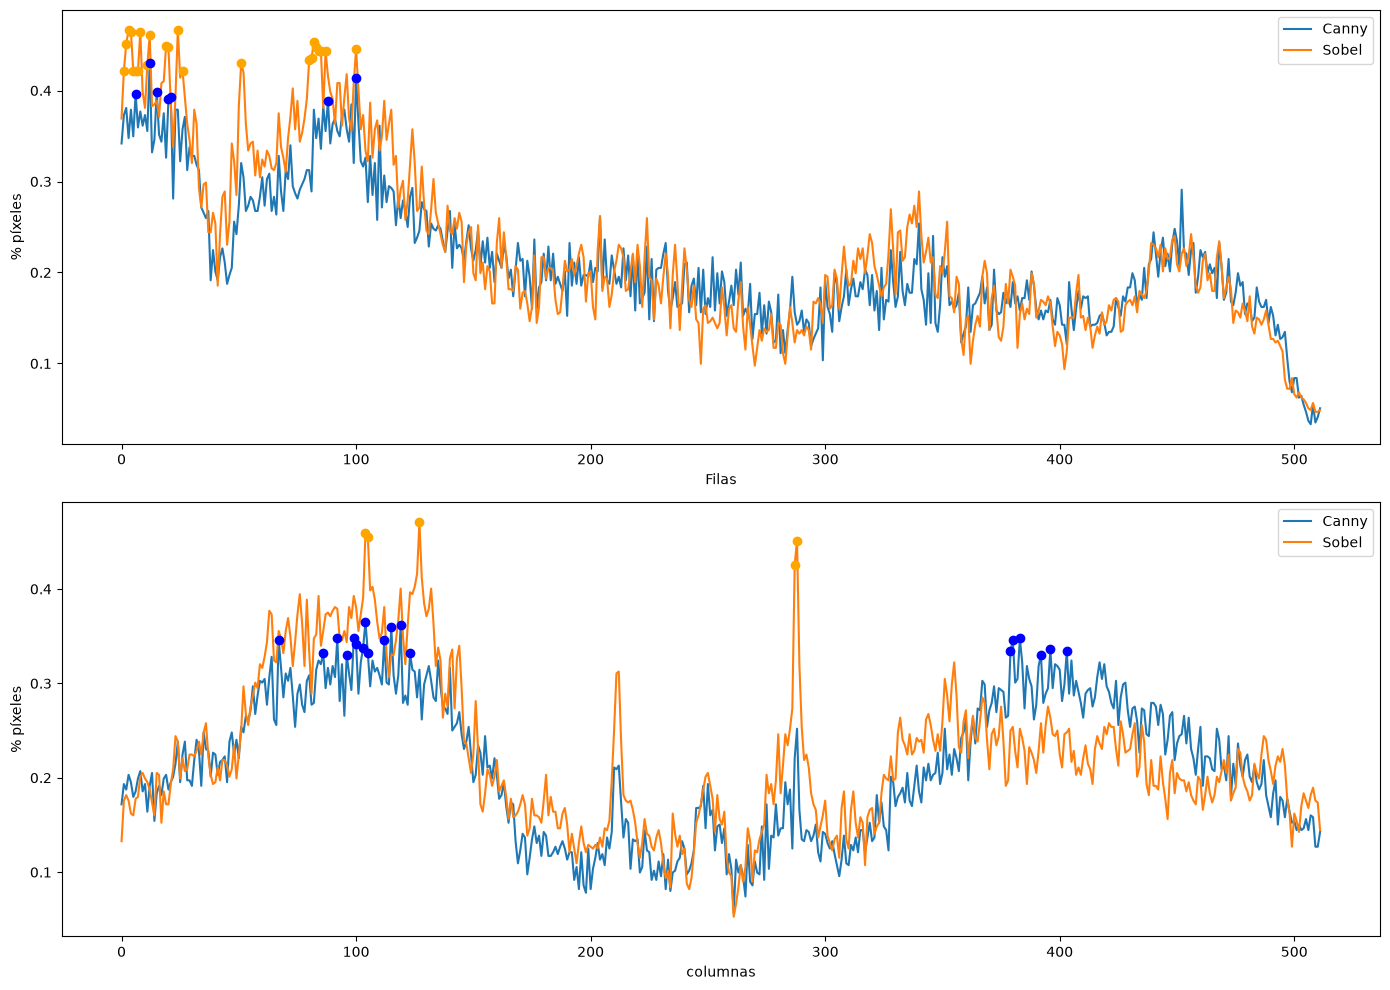

In [30]:
# Imagen de sobel
# Gaussiana para suavizar la imagen original, eliminando altas frecuencias
ggris = cv2.GaussianBlur(gris, (3, 3), 0)

#Calcula en ambas direcciones (horizontal y vertical)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y
#Combina ambos resultados
sobel = cv2.add(sobelx, sobely)
# Conversión a byte con openCV
sobel8 = cv2.convertScaleAbs(sobel)


valorUmbral = 90 
_, imagenUmbralizada = cv2.threshold(sobel8, valorUmbral, 255, cv2.THRESH_BINARY)

row_count_sobel = cv2.reduce(imagenUmbralizada, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
col_count_sobel = cv2.reduce(imagenUmbralizada, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

rows_sobel = row_count_sobel[:,0] / (255 * imagenUmbralizada.shape[1])
max_val_sobel, umbral_sobel, position_row_sobel = calculate_maxUmbral(rows_sobel)
cols_sobel = col_count_sobel[0] / (255 * imagenUmbralizada.shape[0])
max_val_sobel, umbral_sobel, position_col_sobel = calculate_maxUmbral(cols_sobel)


plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray') 


plt.subplot(2, 2, 2)
plt.axis("off")
plt.title("Sobel Umbralizado")
plt.imshow(imagenUmbralizada, cmap='gray')

plt.show()

img_sobel_marcada = imagenUmbralizada.copy()
img_canny_marcada = canny.copy()

plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 1)
plt.axis("off")
plt.title("Canny rojo columnas, azul filas")
plt.imshow(img_canny_marcada, cmap='gray') 
plt.plot(np.zeros_like(position_row_canny), position_row_canny, 'bo')  
plt.plot(position_col_canny,np.zeros_like(position_col_canny), 'ro')  


plt.subplot(2, 2, 2)
plt.axis("off")
plt.title("Sobel Umbralizado: Rojo columnas, Azul filas")
plt.imshow(img_sobel_marcada, cmap='gray')
plt.plot(np.zeros_like(position_row_sobel), position_row_sobel, 'bo')
plt.plot(position_col_sobel, np.zeros_like(position_col_sobel), 'ro')
plt.show()

plt.figure(figsize=(14, 10))
plt.subplot(2, 1, 1)
plt.plot(rows_canny, label="Canny")
plt.plot(rows_sobel, label="Sobel")
plt.plot(position_row_sobel, rows_sobel[position_row_sobel], 'o', color='orange')
plt.plot(position_row_canny, rows_canny[position_row_canny], 'bo')
plt.xlabel("Filas"); plt.ylabel("% píxeles"); plt.legend()
plt.tight_layout()

plt.subplot(2, 1, 2)
plt.plot(cols_canny, label="Canny")
plt.plot(cols_sobel, label="Sobel")
plt.plot(position_col_sobel, cols_sobel[position_col_sobel], 'o', color='orange')
plt.plot(position_col_canny, cols_canny[position_col_canny], 'bo')
plt.xlabel("columnas"); plt.ylabel("% píxeles"); plt.legend()
plt.tight_layout()
plt.show()




Al visualziar los resultados obtenidos mediante el umbralizado de sobel frente a la salida del Canny, podemos observar claramente el efecto de procesar la imagen por etapas.

Canny se construye precisamente sobre la gradiente de Sobel, mientras que en nuestro procedimiento manul con sobel debemos aplicar un umbralizado global, Canny añade etapas haciendo uso del filtro gausiano para reduicr el ruido, afinando los bordes con 1 pixel de grosor y un umbralizado.

El resultado es que Sobel umbralizado, los bordes tienden a ser más gruesos y mayor cantidad de ruido. Provocando que al realizar el conteo de filas y columnas pueden verse altos debido al grosool de las líneas y el rudio.

Por lo contario, Canny, observamos bordes continuos, más finos y deifnidos. En conclusión, el ejercicio ilustra cómo las etapas adicionales de Canny refinan la información.

TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

In [3]:
# Definimos un pequeño "Sistema de Partículas" para las burbujas
class Burbuja:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.vx = random.uniform(-2, 2)
        self.vy = random.uniform(-6, -2) 
        self.radio = random.randint(5, 25) 
        
        # Colores aleatorios estilo neón/burbuja de jabón (Formato BGR en OpenCV)
        self.color = (random.randint(150, 255), random.randint(200, 255), random.randint(200, 255))
        self.vida = 255 # Tiempo de vida antes de explotar/desaparecer

    def actualizar(self):
        # Actualizamos posición
        self.x += self.vx
        self.y += self.vy
        self.vida -= 4 #Envejecimiento de la burbuja
        self.vx += random.uniform(-0.5, 0.5) #Movimiento aleatorio para simular el efecto de flotar



In [ ]:
import cv2
import numpy as np
import random

vid = cv2.VideoCapture(0)
eliminadorFondo = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=50, detectShadows=False)

# Lista para guardar todas las burbujas activas en la pantalla
lista_burbujas = []

while True:
    ret, frame = vid.read()
    if ret:
        
        frame = cv2.flip(frame, 1)
        objetos = eliminadorFondo.apply(frame)
        
        filas = cv2.reduce(objetos, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)[:, 0]
        cols = cv2.reduce(objetos, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)[0]
        val_max_fila = int(np.max(filas))
        val_max_col = int(np.max(cols))
        umbral = 5000

        if val_max_fila > umbral and val_max_col > umbral:
            max_val, umbral, position_row = calculate_maxUmbral(filas)
            max_val_col, umbral_col, position_col = calculate_maxUmbral(cols)

            num_burbujas = int(max_val / 5000)
            num_burbujas = min(num_burbujas, 4) # Limite

            for x in range(num_burbujas):
                bx = random.randint(0, frame.shape[1])
                by = random.randint(0, frame.shape[0])
                lista_burbujas.append(Burbuja(bx, by))
            
        
        for burbuja in lista_burbujas[:]: # Iteramos sobre una copia de la lista
            burbuja.actualizar() #actualizamos la posición y vida de la burbuja
            # Si la burbuja se sale por arriba o su vida se acaba, la borramos
            if burbuja.vida <= 0 or burbuja.y < 0 or burbuja.x < 0 or burbuja.x > frame.shape[1]:
                lista_burbujas.remove(burbuja)
            else:
                # Dibujar la burbuja (grosor 2 para que sea hueca)
                cv2.circle(frame, (int(burbuja.x), int(burbuja.y)), int(burbuja.radio), burbuja.color, 2)

        cv2.imshow('Generador de Burbujas por Movimiento', frame)

    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()